# Kmeans clustering

# Import libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Import - Preprocess the dataset

In [60]:
dataset = pd.read_csv('synthetic_2d_outliers.csv', header=None, on_bad_lines='skip').apply(pd.to_numeric, errors='coerce')
dataset = dataset.dropna()
X = dataset.to_numpy()
scaler = StandardScaler()
X = scaler.fit_transform(X)


# Use elbow methot - silhouette to find optimal number of clusters


Best k with sihlouette is:  4


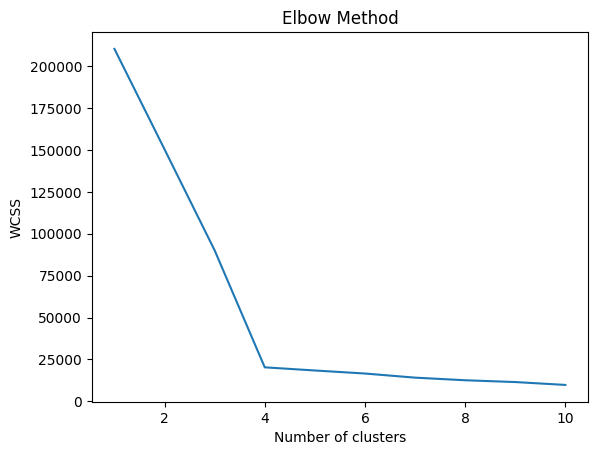

In [61]:
wcss = []
sil_scores = []
for i in range(1,11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state=42)
  kmeans.fit(X)
  #find the wcss value and append it, this is done with inertia_
  if (i>=2):
    #needed too much time to compute with full dataset
    sil = silhouette_score(X, kmeans.labels_, sample_size=10000, random_state=42)
    sil_scores.append(sil)
  wcss.append(kmeans.inertia_)

#store the best silhouette score
best_k_sil = np.argmax(sil_scores) + 2
print('Best k with sihlouette is: ', best_k_sil)
#plot for each cluster the wcss value
plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Train K-Means model on the dataset

In [62]:
kmeans = KMeans(n_clusters = best_k_sil, init = 'k-means++', random_state=42)
#return the dependant variable
y_kmeans = kmeans.fit_predict(X)
print(y_kmeans[:50])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2]


# Detect outliers

In [63]:

k = 7 #number of neighbours we are looking
pct = 99.99 # percentage of the the cluster that is defined as inlier
labels = y_kmeans #cluster labels eg 0,1,2,...
n = X.shape[0] #fetch me all the length of the rows

outlier_mask = np.zeros(n, dtype=bool) #create a table filled with zeros len n

for c in np.unique(labels): #for each cluster
    idx = np.where(labels == c)[0] #find the ind of the points that correspond to each cluster
    X_c = X[idx] #store them in this table

    # if cluster is too small skip
    if len(X_c) <= k:
        continue

    n_neighbors = min(k+1, len(X_c))
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(X_c) #create a structure
    dists, indices = nbrs.kneighbors(X_c) #store distances and their indices
    #dist shape is (cluster point, neighbors)

    mean_dist = dists[:,1:].mean(axis=1)  #mean distance for each point

    # pct of points has distance lower that the threshold, store it in thr
    thr = np.percentile(mean_dist, pct)

    # create a bool array depending if it is more or less than th thr
    cluster_outliers = mean_dist > thr   # shape: (m,)

    # write on global mask
    outlier_mask[idx] = cluster_outliers
#keep only the outliers
outliers = X[outlier_mask]

#print(outliers)

# Visualise the clusters

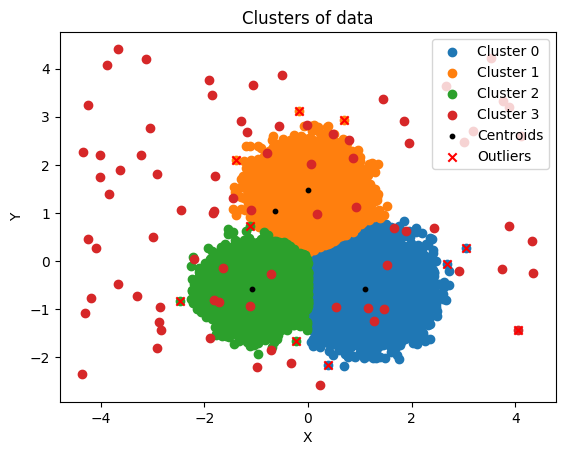

In [64]:
for i in range(best_k_sil):
  plt.scatter(X[y_kmeans==i,0], X[y_kmeans==i,1], label = 'Cluster ' + str(i))
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=10, c='black', label='Centroids')
plt.scatter(outliers[:,0], outliers[:,1],c='red', label='Outliers', marker='x')
plt.title('Clusters of data')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()
